### Read individual .csv files with predictions and store as one single .csv

In [390]:
import os
from pathlib import Path
import glob
import re
import sys
import time
from datetime import datetime
import pandas as pd
import numpy as np
from obspy import read
import numpy as np
import matplotlib.pyplot as plt

# Define the type of waveforms used e.g. "earthquakes", "explosions"
waveform_type = "earthquakes"
# Define the model e.g. "eqcct", "eqt"
model_type = "eqcct"

# Path for .mseed data
data_dir = f"../data/waveforms_{waveform_type}_nonoise/"

# Base path: where to gather the outputs from
# csv output path: where to store the combined csv
base_path = "../results/csv/" 
#subdir = "eqcct_earthquakes_th0_1"
subdir = f"{model_type}_{waveform_type}_th0_1"

csv_output_path = os.path.join(base_path, "combined")
csv_output_name = subdir + "_full.csv"

# Match filenames to only get the csv outputs
files = list(Path(base_path + subdir).rglob("*.csv"))

# Sort files by timechunk folder name (0 = station, 1 = timechunk)
files = sorted(files, key=lambda x:x.parents[1].name)

# Load files
dfs = []

# Start and end times of the time windows as in the folder names
pattern = re.compile(r"(?P<start>\d{8}T\d{6}Z)_(?P<end>\d{8}T\d{6}Z)")
for file in files:
    df_tmp = pd.read_csv(file)

    # Extract time window from folder name
    # e.g. .../20250101T092157Z_20250101T092257Z/HEF_outputs/X_prediction_results.csv
    folder = file.parents[1].name

    m = pattern.match(folder)
    if not m:
        raise ValueError(f"Could not parse folder name: {folder}")

    start_dt = pd.to_datetime(m.group("start"), format="%Y%m%dT%H%M%SZ")
    end_dt = pd.to_datetime(m.group("end"), format="%Y%m%dT%H%M%SZ")

    # Attach to dataframe
    df_tmp["start_dt"] = start_dt
    df_tmp["end_dt"] = end_dt

    # Store the filename of the waveform
    df_tmp["source_file"] = str(file.relative_to(base_path))
    dfs.append(df_tmp)

# Combine into single df
df = pd.concat(dfs, ignore_index=True)

# Keep only rows with predictions
pred_cols = ["p_probability", "s_probability"]

# Extract raw datetime string from time window directories
mseed_pattern = r"(?P<station>[^/]+)/(?P<network>[^.]+)\.(?P=station)\.\.(?P<channel>[A-Z]{3})__(?P<start_dt>\d{8}T\d{6}Z)__(?P<end_dt>\d{8}T\d{6}Z)\.mseed"
matches = df["file_name"].str.extract(mseed_pattern)

# If filename information is present in predictions, use it to infer network and station codes
# This is done because eqcct assigns 0 as the network code for some reason
if matches.notna().all().all():
    df["network"] = matches["network"].str.strip().str.upper()
    df["station"] = matches["station"].str.strip().str.upper()

# With EQT, the .mseed filename is not available, but network and station should be correct in the predictions .csv
else:
    df["network"] = df["network"].str.strip().str.upper()
    df["station"] = df["station"].str.strip().str.upper()

# Convert arrivals to datetime
df["p_arrival_time"] = pd.to_datetime(df["p_arrival_time"], errors="coerce")
df["s_arrival_time"] = pd.to_datetime(df["s_arrival_time"], errors="coerce")

# Filter out rows with NaN for both p_probability and s_probability (no predicted picks)
df = df[df["p_probability"].notna() | df["s_probability"].notna()]

# Sort df by the window start time
df = df.sort_values(by="start_dt", ascending=True)
# Save dataframe to csv
os.makedirs(csv_output_path, exist_ok=True)
df.to_csv(os.path.join(csv_output_path, csv_output_name), index=False)

# Print some basic information about the number of predicted picks
num_rows = len(df)
num_files = len(files)
num_p_picks = sum(df["p_probability"].notna())
num_s_picks = sum(df["s_probability"].notna())
num_negatives = sum(df["p_probability"].isna() & df["s_probability"].isna())

print(f"Read {num_rows} rows from {num_files} files.")
print(f"Number of predicted p-arrivals: {num_p_picks}\nNumber of predicted s-arrivals: {num_s_picks}\nTotal number of arrivals: {num_p_picks+num_s_picks}")
print(f"Number of empty predictions: {num_negatives}")

Read 2071 rows from 2417 files.
Number of predicted p-arrivals: 2060
Number of predicted s-arrivals: 1473
Total number of arrivals: 3533
Number of empty predictions: 0


### Plot waveforms and predicted p/s picks

In [391]:
from obspy import Stream, UTCDateTime
from collections import defaultdict

def build_waveform_index(data_dir):

    index = defaultdict(list)

    # Patterns to match
    # .mseed filename
    file_pattern = re.compile(r"(?P<network>[^.]+)\.(?P<station>[^.]+)\.\.(?P<channel>[A-Z0-9]+)__(?P<start>\d{8}T\d{6}Z)__(?P<end>\d{8}T\d{6}Z)\.mseed")
    # directory containing time window e.g. "20250102T044222Z_20250102T044322Z"
    dir_pattern = re.compile(r"(?P<start>\d{8}T\d{6}Z)_(?P<end>\d{8}T\d{6}Z)")

    for entry in os.scandir(data_dir):
        if not entry.is_dir():
            continue

        dir_match = dir_pattern.fullmatch(entry.name)
        if not dir_match:
            continue

        dir_start = dir_match.group("start")
        dir_end = dir_match.group("end")

        # Iterate over .mseed files in the subdirectories
        for root, _, files in os.walk(entry.path):
            for f in files:
                if not f.endswith(".mseed"):
                    continue

                f = f.strip()
                m = file_pattern.fullmatch(f)
                if not m:
                    print("No match:", f)
                    continue

                network = m.group("network")
                station = m.group("station")

                key = (network, station, dir_start, dir_end)
                path = os.path.join(root, f)

                index[key].append(path)

    return index


# Load a time window at a given network and station
def load_station_window(index, network, station, start_dt, end_dt):

    # Convert datetime of time windows to match the format in the directory names
    start_str = UTCDateTime(start_dt).strftime("%Y%m%dT%H%M%SZ")
    end_str = UTCDateTime(end_dt).strftime("%Y%m%dT%H%M%SZ")

    key = (network, station, start_str, end_str)

    st = Stream()

    if key not in index:
        print("Missing waveform:", key)
        return st

    for path in index[key]:
        st += read(path)

    if len(st) == 0:
        return st

    start = UTCDateTime(start_dt)
    end = UTCDateTime(end_dt)
    st.merge(method=1, fill_value="interpolate")
    st.trim(start, end)

    return st


# Plot a row from the prediction results dataframe
def plot_pred_row(row, waveform_idx, p_tr=0.01):

    # Skip low-probability rows
    if not (
        (pd.notna(row.p_probability) and row.p_probability > p_tr) or
        (pd.notna(row.s_probability) and row.s_probability > p_tr)
    ):
        return

    st = load_station_window(
        waveform_idx,
        row.network,
        row.station,
        row.start_dt,
        row.end_dt
    )

    if len(st) == 0:
        print("No waveform:", row.station, row.start_dt)
        return

    # Downsample to 100Hz if needed
    for tr in st:
        if tr.stats.sampling_rate > 100:
            tr.resample(100)

    # Generate the plot
    fig, axes = plt.subplots(3,1,figsize=(10,6),sharex=True)
    fig.suptitle(f"{row.network}.{row.station}  {row.start_dt} to {row.end_dt}", fontsize=10)

    # Get the list of channels for the current stream
    channels = [tr.stats.channel for tr in st]

    for j, ch in enumerate(channels):
        # Trace for currently selected channel
        tr_sel = st.select(channel=ch)
        # Don't plot if there are no traces
        if len(tr_sel) == 0:
            continue

        # Waveform processing
        tr = tr_sel[0].copy()
        tr.detrend("linear")
        tr.detrend("demean")
        tr.filter("bandpass", freqmin=1, freqmax=45, corners=2, zerophase=True)
        tr.taper(max_percentage=0.01, type='cosine', max_length=2)
        tr.normalize()

        # Time axis
        t = tr.times()
        
        axes[j].plot(t, tr.data, color="grey", linewidth=1)

        # Predicted p-arrival
        if pd.notna(row.p_arrival_time):
            time_pred = UTCDateTime(row.p_arrival_time) - tr.stats.starttime
            axes[j].axvline(time_pred, color="b", linewidth=1.5, linestyle="dashed", label=f"P-pred (p={row.p_probability:.3f})")

        # Predicted s-arrival
        if pd.notna(row.s_arrival_time):
            time_pred = UTCDateTime(row.s_arrival_time) - tr.stats.starttime
            axes[j].axvline(time_pred, color="r", linewidth=1.5, linestyle="dashed", label=f"S-pred (p={row.s_probability:.3f})")

        axes[j].set_ylabel(ch)
        axes[j].legend(loc="lower right")

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

    return True

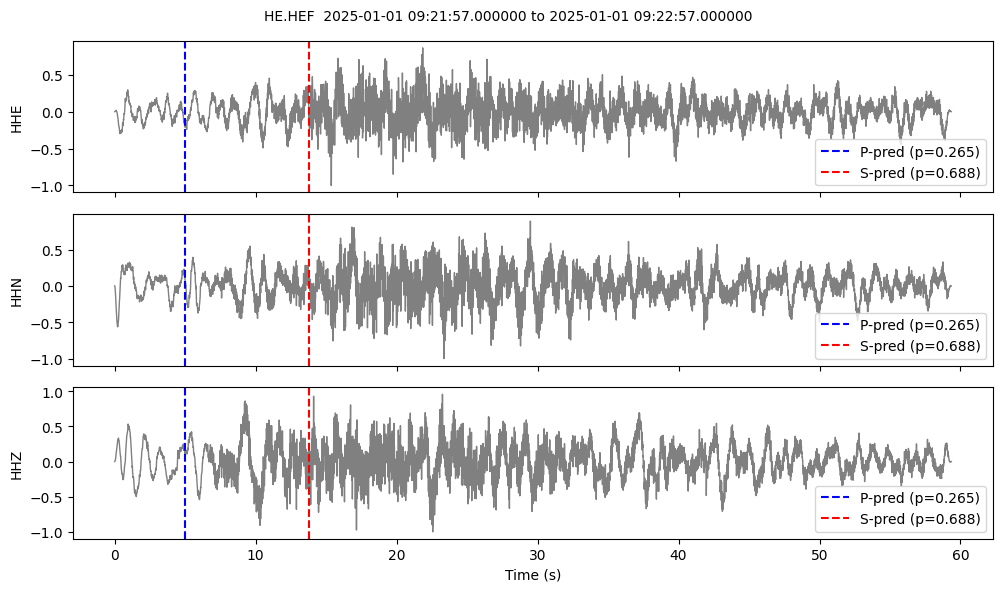

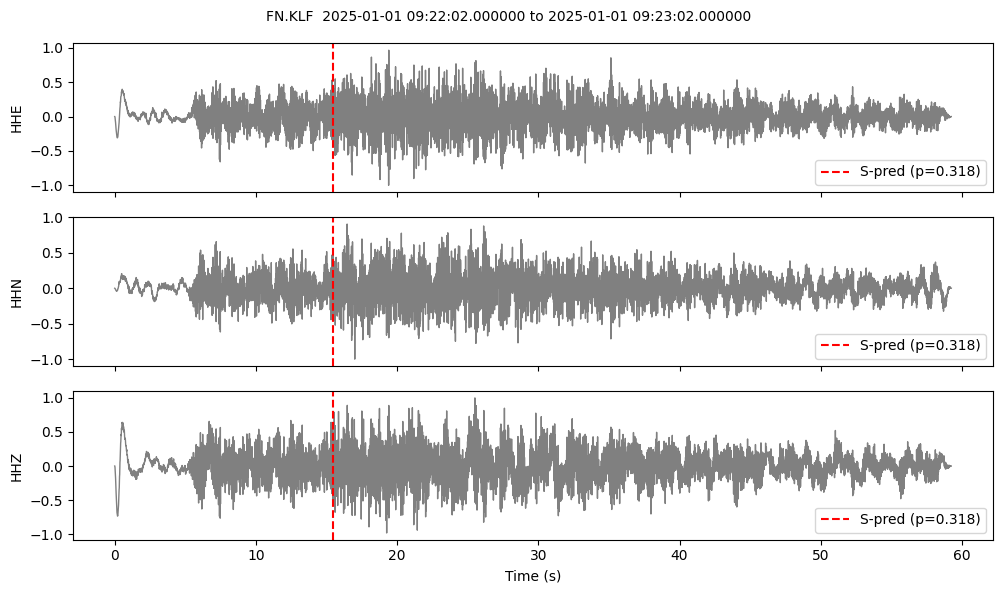

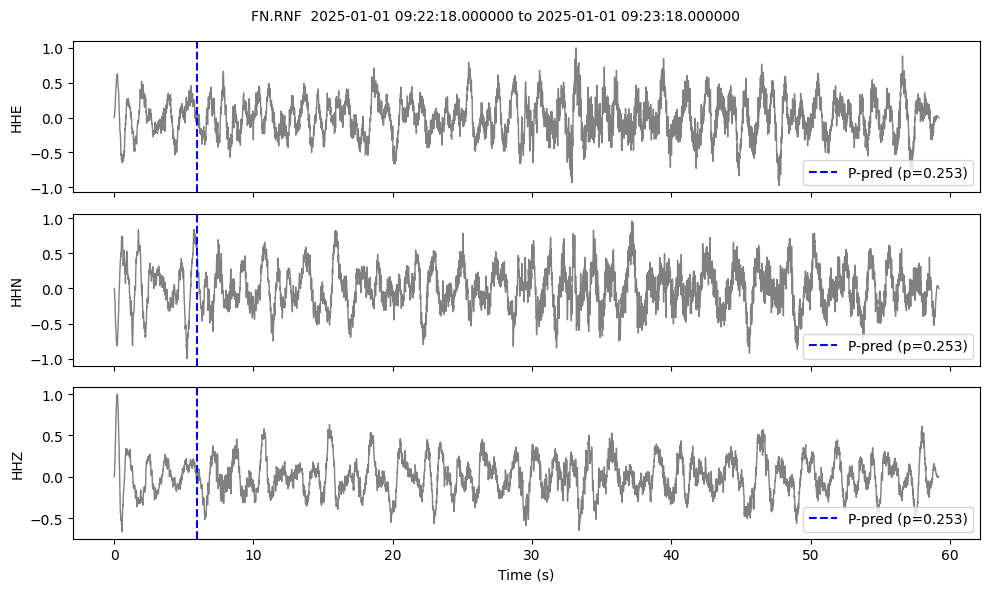

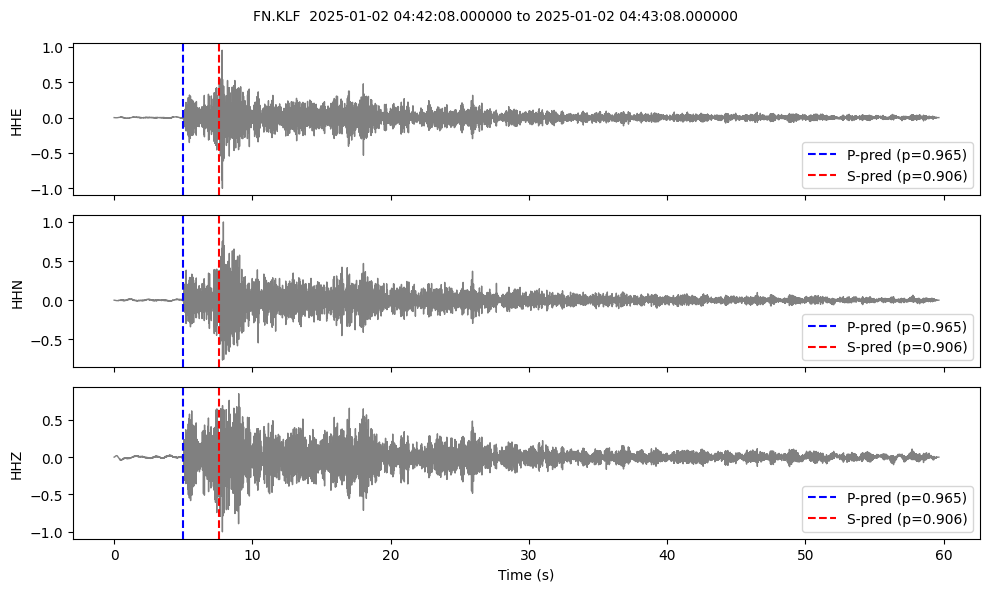

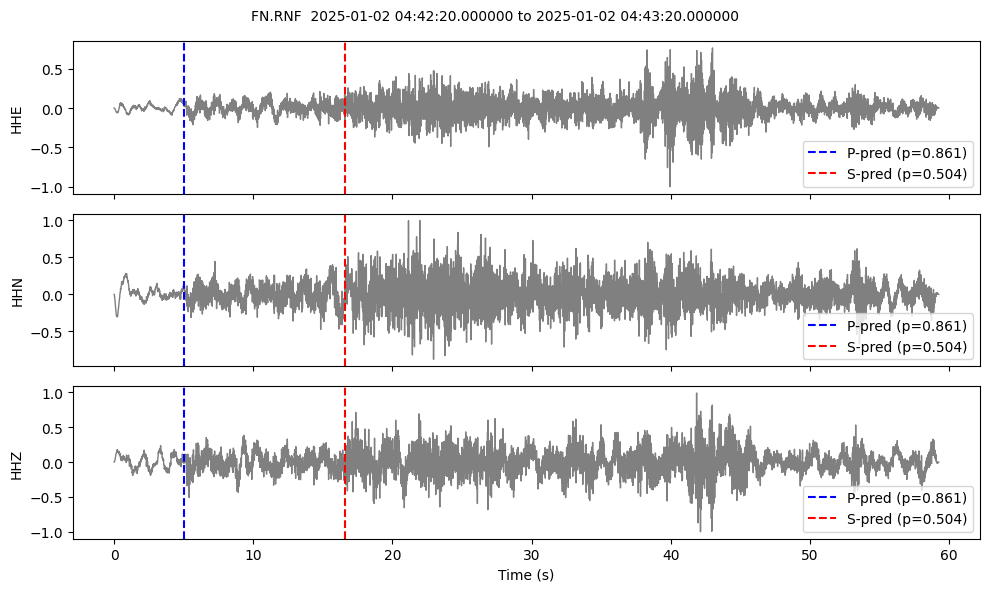

In [392]:
# Build indices for the waveforms
waveform_idx = build_waveform_index(data_dir)

# Load data from .csv file with combined predictions
df = pd.read_csv(os.path.join(csv_output_path, csv_output_name))

# Test plots
num_plots = 5
counter = 0

for _, row in df.head(20).iterrows():
    plotted = plot_pred_row(row, waveform_idx)
    if plotted:
        counter += 1
        if counter >= num_plots:
            break

### Load quake-ML files with true picks

In [393]:
from obspy import read_events
import geopandas as gpd
from shapely.geometry import Point

qml_dir = Path("../data/qml_files")

paths = {
    "earthquakes": qml_dir / "earthquakes2025.qkml",
    "explosions": qml_dir / "explosions2025.qkml",
}

catalogs = {}
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
    catalogs[name] = read_events(str(path))
    print(f"{name}: {len(catalogs[name])} events loaded from {path.name}")

earthquakes: 328 events loaded from earthquakes2025.qkml
explosions: 599 events loaded from explosions2025.qkml


### Inspect .qml event information

In [394]:
# Earthquake events catalog
eq_cat = catalogs[f"{waveform_type}"]
print(eq_cat)

# Inspect a single event by index
i = 0
event = eq_cat[i]
print(f"\nSingle event (index = {i}):")
print(event)
print("origins:", len(event.origins))          # number of location solutions
print("magnitudes:", len(event.magnitudes))    # number of magnitude estimates
print("picks:", len(event.picks))              # total phase picks across stations
print("comments:", event.comments)

for pick in event.picks:
    print(pick)

328 Event(s) in Catalog:
2025-01-01T09:21:53.400000Z | +67.950,  +23.087 | 0.0  ML
2025-01-02T04:42:09.800000Z | +67.059,  +24.110 | 0.2  ML
...
2025-12-28T22:31:37.900000Z | +65.044,  +27.374 | 1.1  ML
2025-12-30T11:43:17.500000Z | +61.567,  +24.258 | 1.1  ML
To see all events call 'print(CatalogObject.__str__(print_all=True))'

Single event (index = 0):
Event:	2025-01-01T09:21:53.400000Z | +67.950,  +23.087 | 0.0  ML

	            resource_id: ResourceIdentifier(id="smi:fi.isuh/event/1490639")
	             event_type: 'earthquake'
	    preferred_origin_id: ResourceIdentifier(id="smi:fi.isuh/origin/1490639")
	 preferred_magnitude_id: ResourceIdentifier(id="smi:fi.isuh/magnitude/1490639")
	                   ---------
	     event_descriptions: 1 Elements
	               comments: 3 Elements
	                  picks: 18 Elements
	             amplitudes: 3 Elements
	       focal_mechanisms: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements
origins: 1


In [395]:
# Look at channels contained in the pick catalogue
all_channels = set()
for event in eq_cat:
    for pick in event.picks:
        if pick.waveform_id is not None:
            all_channels.add(pick.waveform_id.channel_code.upper())

print(sorted(all_channels))

channel_counter = defaultdict(int)
for event in eq_cat:
    for pick in event.picks:
        if pick.waveform_id is not None:
            channel_counter[pick.waveform_id.channel_code.upper()] += 1

print(channel_counter)

['?HE', '?HN', '?HZ', 'BHE', 'BHN', 'BHZ', 'CE', 'CN', 'CZ', 'SHN', 'SHZ']
defaultdict(<class 'int'>, {'BHZ': 5454, 'BHN': 38, '?HZ': 2020, 'CZ': 1072, 'SHZ': 315, '?HE': 5, '?HN': 11, 'BHE': 6, 'CN': 8, 'SHN': 1, 'CE': 2})


### Compile true p- and s-picks into dataframe

In [396]:
# Create a dictionary only for networks/stations contained in predictions
station_dict = {ntwk: df[df["network"] == ntwk]["station"].unique().tolist()
                for ntwk in df["network"].unique()}

# Extract picks from earthquake catalogue
p_alias = {"P", "PG", "PB", "PN"}
s_alias = {"S", "SG", "SB", "SN"}

event_ids = []
times = []
networks = []
stations = []
phases = []
channels = []

for event in eq_cat:
    event_id = event.resource_id

    # Get pick information per event
    for pick in event.picks:
        pick_time = pick.time
        # Only get pick information if a waveform is available
        if pick.waveform_id is None:
            continue

        # Only consider picks using the same channels as the predictions are based on
        channel = pick.waveform_id.channel_code
        #if channel not in {"SHN", "SHE", "SHZ"}:
        #    continue

        pick_network = pick.waveform_id.network_code
        pick_station = pick.waveform_id.station_code
        pick_phase_hint = pick.phase_hint
        
        # Ensure that picks belong to the same list of networks and stations as predictions
        if pick_network in station_dict.keys() and pick_station in station_dict[pick_network]:
            if pick_phase_hint:
                ph = (pick_phase_hint or "").upper().strip()
                if ph in p_alias:
                    pick_phase = "P"
                elif ph in s_alias:
                    pick_phase = "S"
                else:
                    continue
            
            # Append pick information to lists
            event_ids.append(event_id)
            times.append(pick_time.datetime)
            networks.append(pick_network)
            stations.append(pick_station)
            phases.append(pick_phase)
            channels.append(channel)

# Compile data to dataframe
df_true = pd.DataFrame({"true_arrival_time": times, "network": networks, "station": stations, "phase": phases, "channel": channels})

# Sort by the pick time
df_true = df_true.sort_values(by="true_arrival_time", ascending=True)

# Print number of respective phase types
print(df_true["phase"].value_counts())

# Store ground truth in csv/ground_truth
gt_path = os.path.join(base_path, "ground_truth")
gt_fname = subdir + ".csv"
os.makedirs(gt_path, exist_ok=True)
df_true.to_csv(os.path.join(gt_path, gt_fname), index=False)

S    2433
P    1578
Name: phase, dtype: int64


### Alternative: Use the labels instead (likely less error-prone)

In [397]:
# Insert network, station and channel into the labels and store as the ground truth
# labels_dict = {"ex": "explosions", "eq": "earthquakes"}

# for key, value in labels_dict.items():
#     # Load data
#     df_labels = pd.read_csv(f"../data/{key}_labels.csv")

#     # Split file_name
#     split_col = df_labels["file_name"].str.split(r"\s*\|\s*", expand=True)
#     station_info = split_col[0].str.split(".", expand=True)

#     df_labels["network"] = station_info[0]
#     df_labels["station"] = station_info[1]
#     df_labels["channel"] = station_info[3]

#     # Create rows (separate p and s picks)
#     rows = []

#     for _, r in df_labels.iterrows():
#         # P-pick
#         if pd.notna(r["p_arrival_time"]):
#             rows.append({
#                 "true_arrival_time": r["p_arrival_time"],
#                 "network": r["network"],
#                 "station": r["station"],
#                 "phase": "P",
#                 "channel": r["channel"]
#             })

#         # S-pick
#         if pd.notna(r["s_arrival_time"]):
#             rows.append({
#                 "true_arrival_time": r["s_arrival_time"],
#                 "network": r["network"],
#                 "station": r["station"],
#                 "phase": "S",
#                 "channel": r["channel"]
#             })

#     df_out = pd.DataFrame(rows)

#     df_out["true_arrival_time"] = pd.to_datetime(df_out["true_arrival_time"], utc=True).dt.tz_convert(None)

#     # Sort by the pick time
#     df_out = df_out.sort_values(by="true_arrival_time", ascending=True)
    
#     # Save to .csv file
#     df_out.to_csv(f"../results/csv/ground_truth/{value}_gt.csv", index=False)

### Match and merge dataframes for predictions and actual picks

In [ ]:
# Load ground truth
df_true = pd.read_csv(f"../results/csv/ground_truth/{model_type}_{waveform_type}_th0_1.csv")

# Adjustable thresholds
p_threshold = 0.1
time_threshold = "0.5s"

# Split predicted p-arrivals and s-arrivals into dataframes
df_pred = df.sort_values("start_dt")
df_pred_p = df_pred[["network", "station", "p_arrival_time", "p_probability", "start_dt", "end_dt"]].rename(columns={"p_arrival_time": "pred_arrival_time", "p_probability": "probability"})
df_pred_s = df_pred[["network", "station", "s_arrival_time", "s_probability", "start_dt", "end_dt"]].rename(columns={"s_arrival_time": "pred_arrival_time", "s_probability": "probability"})

# Add a phase column
df_pred_p["phase"] = "P"
df_pred_s["phase"] = "S"

# Concatenate into one longer dataframe
df_pred_long = pd.concat([df_pred_p, df_pred_s], ignore_index=True)
df_pred_long = df_pred_long.dropna(subset=["pred_arrival_time", "probability"])
df_pred_long = df_pred_long[df_pred_long["probability"] > p_threshold]

# Convert to standard datetime
df_pred_long["pred_arrival_time"] = pd.to_datetime(df_pred_long["pred_arrival_time"])
df_true["true_arrival_time"] = pd.to_datetime(df_true["true_arrival_time"])

# Keep only P and S-picks from ground truth
df_true = df_true[df_true["phase"].isin(["P", "S"])]

# Sort by datetime for both
df_pred_long = df_pred_long.sort_values("pred_arrival_time")
df_true = df_true.sort_values("true_arrival_time")

# How much time between predictions and true picks to accept
delta = pd.Timedelta(time_threshold)

# Dataframe merging predictions on ground truth -> TP and FP
preds_on_picks = pd.merge_asof(
    df_pred_long,
    df_true,
    left_on="pred_arrival_time",
    right_on="true_arrival_time",
    by=["network", "station", "phase"],
    tolerance=delta,
    direction="nearest"
)

# Dataframe merging ground truth on predictions -> TP and FN
picks_on_preds = pd.merge_asof(
    df_true,
    df_pred_long,
    left_on="true_arrival_time",
    right_on="pred_arrival_time",
    by=["network", "station", "phase"],
    tolerance=delta,
    direction="nearest"
)

# Deduplicate multiple predictions matched on the same true pick
picks_on_preds = picks_on_preds.sort_values(by=["network", "station", "phase", "true_arrival_time", "pred_arrival_time"])
picks_on_preds["time_diff"] = (picks_on_preds["pred_arrival_time"] - picks_on_preds["true_arrival_time"]).abs()
picks_on_preds = (picks_on_preds.sort_values("time_diff").drop_duplicates(subset=["network", "station", "phase", "true_arrival_time"]))

### Early metrics

In [399]:
# Count number of total (true) picks and predictions
num_picks = len(picks_on_preds)
num_preds = len(preds_on_picks)

# Compute TP, FP and FN
TP = picks_on_preds["probability"].notna().sum()
FP = num_preds - TP
FN = num_picks - TP

# Recall = fraction of true picks detected
recall = TP / (TP + FN)

# Precision = fraction of correct predictions
precision = TP / (TP + FP)

# F1 score
f1_score = 2 * (precision * recall) / (precision + recall)

# Filter p and s picks to monitor accuracy difference between the two models
p_picks_on_preds = picks_on_preds[picks_on_preds["phase"] == "P"]
s_picks_on_preds = picks_on_preds[picks_on_preds["phase"] == "S"]
p_preds_on_picks = preds_on_picks[preds_on_picks["phase"] == "P"]
s_preds_on_picks = preds_on_picks[preds_on_picks["phase"] == "S"]

# True positives (Prediction and event match within the given timedelta)
TP_p = p_picks_on_preds["probability"].notna().sum()
TP_s = s_picks_on_preds["probability"].notna().sum()

# "False positives" (Predictions without corresponding event)
FP_p = len(p_preds_on_picks) - TP_p
FP_s = len(s_preds_on_picks) - TP_s

# # False negatives (No prediction for true pick found)
FN_p = len(p_picks_on_preds) - TP_p
FN_s = len(s_picks_on_preds) - TP_s

# Recall
recall_p = TP_p / (TP_p + FN_p)
recall_s = TP_s / (TP_s + FN_s)

# Precision
precision_p = TP_p / (TP_p + FP_p)
precision_s = TP_s / (TP_s + FP_s)

# F1 score
f1_score_p = 2 * (precision_p * recall_p) / (precision_p + recall_p)
f1_score_s = 2 * (precision_s * recall_s) / (precision_s + recall_s)

# Get the metrics as a string
metrics_string = f"""
Evaluated predictions from: {subdir}

=========== Overall metrics ===========
True Positives:        {TP}
False Positives:       {FP}
False Negatives:       {FN}
Total predictions:     {num_preds}
Total picks:           {num_picks}
Recall:                {recall}
Precision:             {precision}
F1 Score:              {f1_score}

=========== Metrics for p-picks ===========
True Positives:        {TP_p}
False Positives:       {FP_p}
False Negatives:       {FN_p}
Total predictions:     {len(p_preds_on_picks)}
Total picks:           {len(p_picks_on_preds)}
Recall:                {recall_p}
Precision:             {precision_p}
F1 Score:              {f1_score_p}

=========== Metrics for s-picks ===========
True Positives:        {TP_s}
False Positives:       {FP_s}
False Negatives:       {FN_s}
Total predictions:     {len(s_preds_on_picks)}
Total picks:           {len(s_picks_on_preds)}
Recall:                {recall_s}
Precision:             {precision_s}
F1 Score:              {f1_score_s}
"""

print(metrics_string)


Evaluated predictions from: eqcct_earthquakes_th0_1

=========== Overall metrics ===========
True Positives:        2783
False Positives:       749
False Negatives:       1228
Total predictions:     3532
Total picks:           4011
Recall:                0.6938419346796311
Precision:             0.7879388448471121
F1 Score:              0.7379026912369083

=========== Metrics for p-picks ===========
True Positives:        1474
False Positives:       586
False Negatives:       104
Total predictions:     2060
Total picks:           1578
Recall:                0.9340937896070975
Precision:             0.7155339805825243
F1 Score:              0.8103353490929082

=========== Metrics for s-picks ===========
True Positives:        1309
False Positives:       163
False Negatives:       1124
Total predictions:     1472
Total picks:           2433
Recall:                0.5380189066995479
Precision:             0.889266304347826
F1 Score:              0.6704225352112676



In [ ]:
# Store metrics in results/metrics/<model_type>_<waveform_type>
# e.g. results/metrics/eqcct_earthquakes
metrics_dir = f"{base_path.replace('csv', 'metrics')}/{model_type}_{waveform_type}_th0_1"
os.makedirs(metrics_dir, exist_ok=True)

file_path = os.path.join(metrics_dir, f"{subdir}.txt")

with open(file_path, "w") as f:
    f.write(metrics_string)
    print(f"Successfully wrote metrics to {file_path}.")

Successfully wrote metrics to ../results/metrics//eqcct_earthquakes_2s_delta/eqcct_earthquakes_th0_1.txt.


/home/tomc/miniconda3/envs/eqcct/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


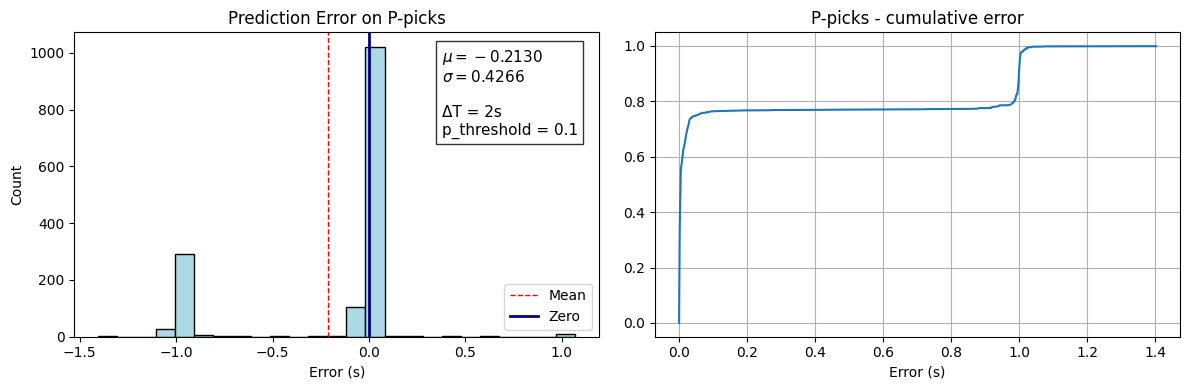

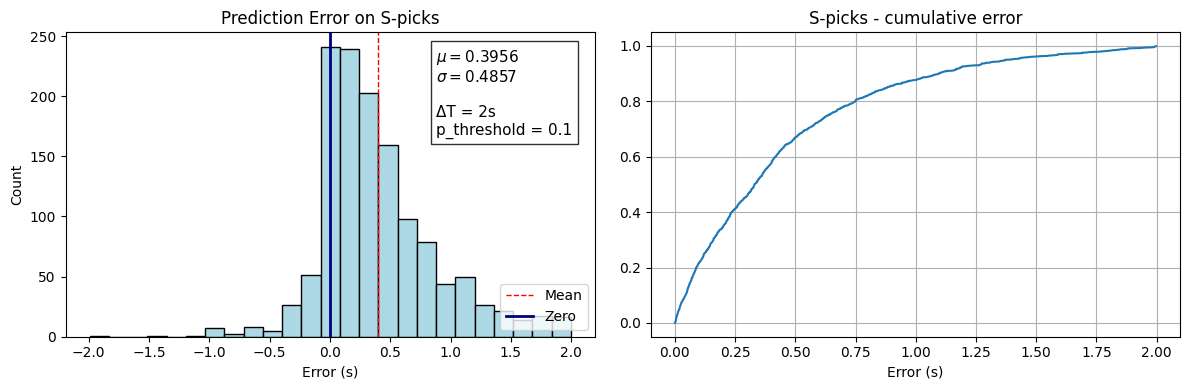

In [ ]:
df_dict = {"P-picks": p_picks_on_preds, "S-picks": s_picks_on_preds}

# Compute error between gt and predictions
for df_name, df2 in df_dict.items():

    df2["error_seconds"] = (df2["pred_arrival_time"] - df2["true_arrival_time"]).dt.total_seconds()
    errors = df2["error_seconds"].dropna()

    # Text string to display some information
    text_string = f"$\\mu={errors.mean():.4f}$\n$\\sigma={errors.std():.4f}$\n\nΔT = {time_threshold}\np_threshold = {p_threshold}"

    # Plotting histogram
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(errors, color="lightblue", edgecolor='black', bins=25)
    axes[0].axvline(errors.mean(), linestyle="dashed", linewidth=1, color="r", label="Mean")
    axes[0].axvline(0, linewidth=2, color="navy", label="Zero")
    
    axes[0].text(0.70, 0.95, text_string,
    transform=axes[0].transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(facecolor='w', alpha=0.8))
    
    axes[0].set_title(f"Prediction Error on {df_name}")
    axes[0].set_xlabel("Error (s)")
    axes[0].set_ylabel("Count")
    axes[0].legend(loc="lower right")

    # Plotting cumulative error
    sorted_err = np.sort(np.abs(errors))
    cdf = np.arange(len(sorted_err)) / len(sorted_err)

    axes[1].plot(sorted_err, cdf)
    axes[1].set_title(f"{df_name} - cumulative error")
    axes[1].set_xlabel("Error (s)")
    axes[1].grid()


    plot_filename = f"{model_type}_{waveform_type}_{df_name.lower().replace('-', '_')}_th0_1.png"

    plt.tight_layout()
    plt.savefig(os.path.join(metrics_dir, plot_filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


### Plot predictions versus true picks (only for correct predictions within e.g. 2s)

In [402]:
def plot_window(group_df, waveform_idx, prob_tr=0.05):
    row0 = group_df.iloc[0]

    st = load_station_window(
        waveform_idx,
        row0.network,
        row0.station,
        row0.start_dt,
        row0.end_dt
    )

    if len(st) == 0:
        print("No waveform")
        return

    # Downsample to 100Hz if needed
    for tr in st:
        if tr.stats.sampling_rate > 100:
            tr.resample(100)
    
    # Generate the plot
    fig, axes = plt.subplots(3,1,figsize=(10,6),sharex=True)
    fig.suptitle(f"{row0.network}.{row0.station}  {row0.start_dt} to {row0.end_dt}", fontsize=10)

    channel_comp = ["N","E","Z"]

    for j, ch in enumerate(channel_comp):

        tr_sel = st.select(channel=f"*{ch}")

        if len(tr_sel) == 0:
            axes[j].set_ylabel(ch)
            continue
        
        # Trace for currently selected channel
        tr = tr_sel[0].copy()

        # Don't plot if there are no traces
        if len(tr_sel) == 0:
            continue

        # Process waveform
        tr = tr_sel[0].copy()
        tr.detrend("linear")
        tr.detrend("demean")
        tr.filter("bandpass", freqmin=1, freqmax=45, corners=2, zerophase=True)
        tr.taper(max_percentage=0.01, type='cosine', max_length=2)
        tr.normalize()

        # Time axis
        t = tr.times()

        # Normalise waveforms
        max_amp = np.max(np.abs(tr.data))
        if max_amp > 0:
            tr.data = tr.data / max_amp

        axes[j].plot(t, tr.data, color="grey", linewidth=1)

        # Plot all picks in the given time window
        for i, (_, pick) in enumerate(group_df.iterrows()):
            if pick.probability < prob_tr:
                continue
            
            # Ensure the predicted and true arrival times cannot be NaN
            time_pred = None
            if pd.notna(pick.pred_arrival_time):
                time_pred = UTCDateTime(pick.pred_arrival_time) - tr.stats.starttime

            time_true = None
            if pd.notna(pick.true_arrival_time):
                time_true = UTCDateTime(pick.true_arrival_time) - tr.stats.starttime

            # Set colour of pick line based on phase type
            if pick.phase == "P":
                c = "r"
                text_x_pos = time_pred-7
                text_y_pos = tr.data.max()*0.7
            elif pick.phase == "S":
                c = "b"
                text_x_pos = time_pred+1
                text_y_pos = tr.data.min()*0.8
            # Plot the predicted picks
            if time_pred is not None:
                axes[j].axvline(time_pred, color=c, linewidth=1.5, label=f'{pick.phase}-predicted (p={pick.probability})')

            # Plot the true picks
            if time_true is not None:
                axes[j].axvline(time_true, color=c, linewidth=1.5, linestyle="dotted", label=f'{pick.phase}-actual')

            # Plot the time delta between ground truth and prediction
            if time_pred is not None and time_true is not None:
                axes[j].text(x=text_x_pos, y=text_y_pos, s=f"delta: {time_true - time_pred:.2f}s", bbox=dict(facecolor='w', alpha=1, edgecolor=c))
        
        axes[j].set_ylabel(ch)

    # Labels and legends
    axes[j].legend(loc='lower right')
    axes[j].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

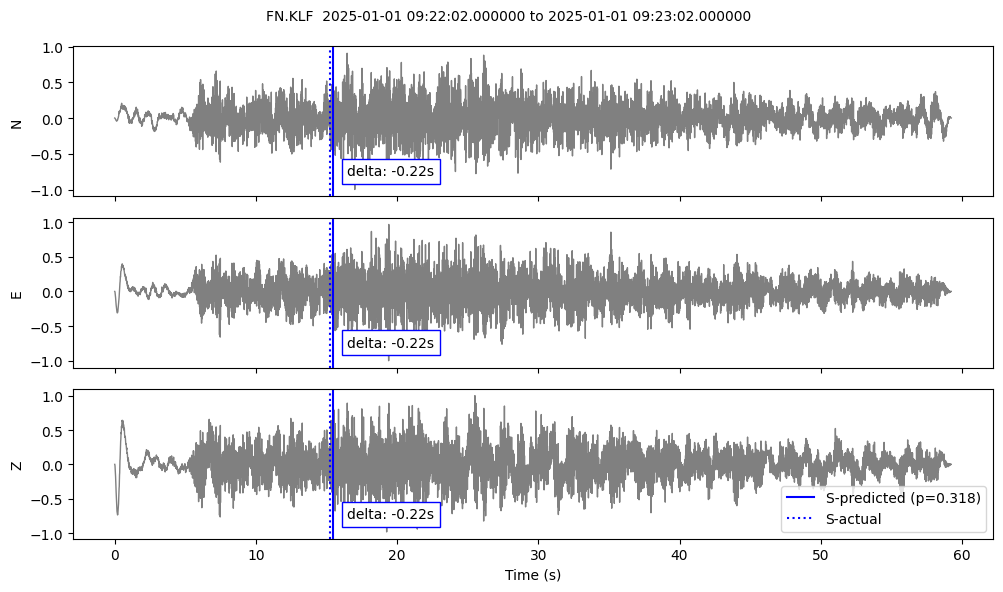

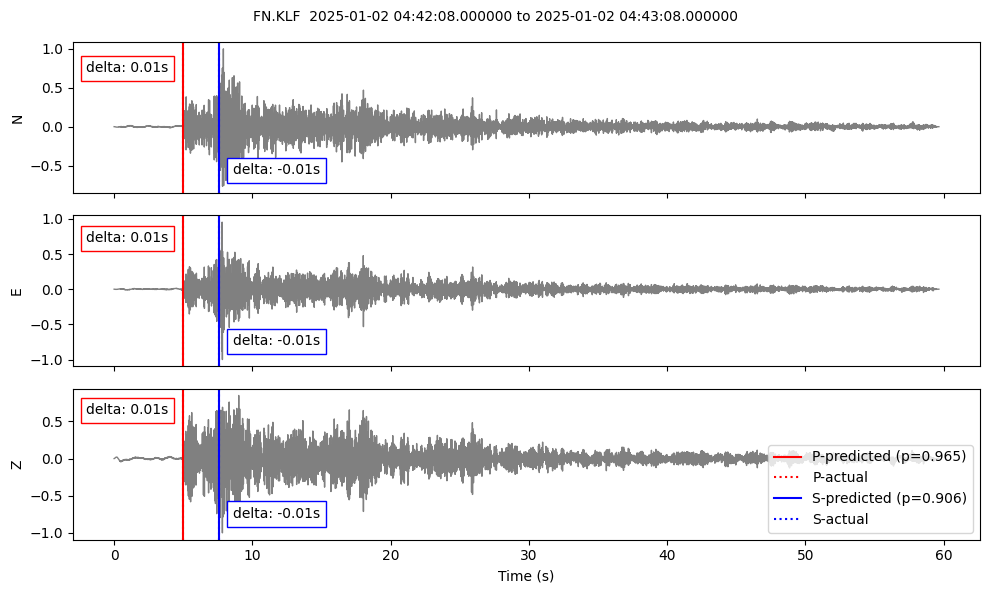

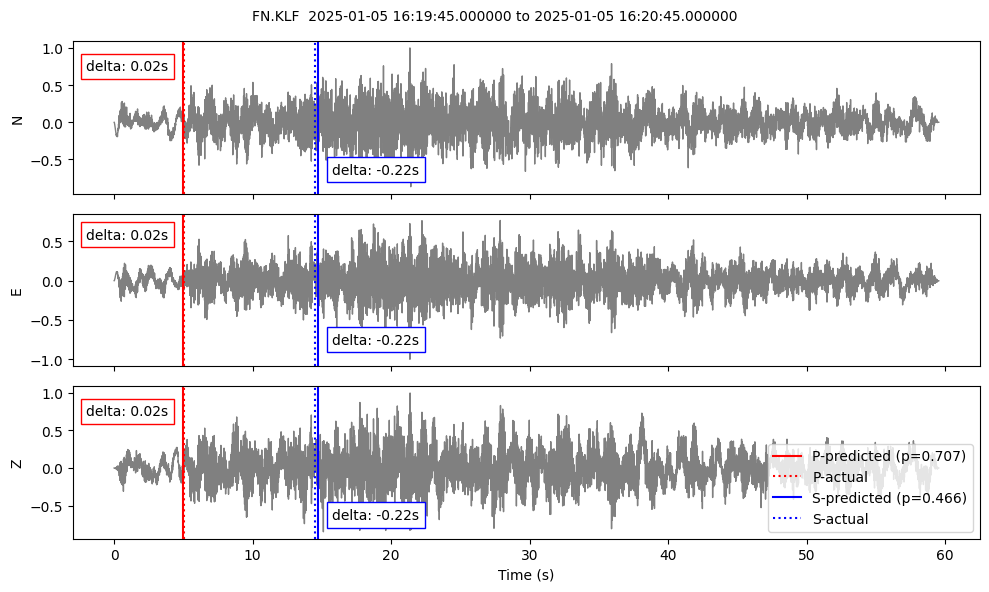

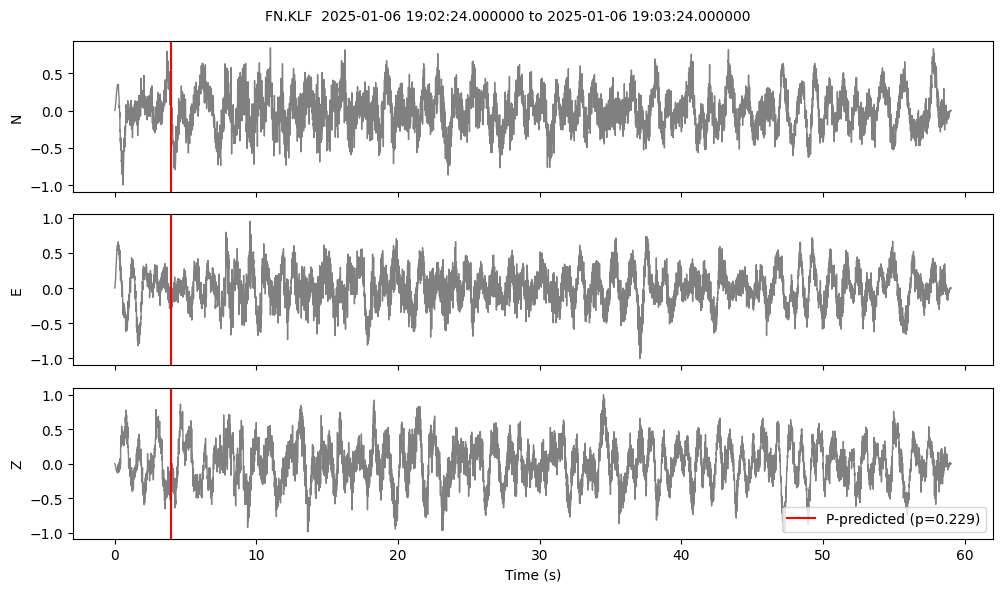

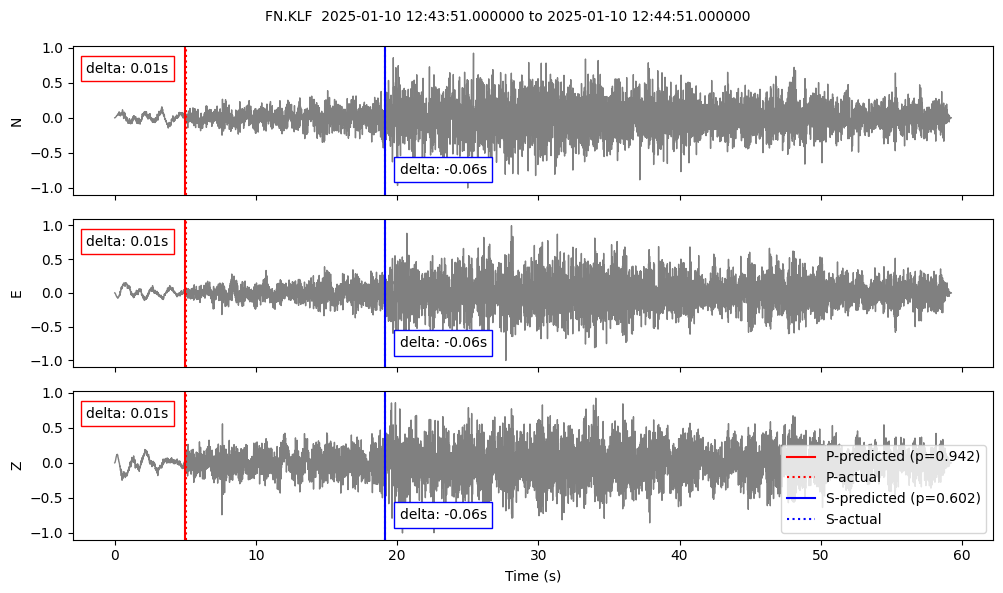

In [403]:
groups = preds_on_picks.groupby(["network","station","start_dt","end_dt"])

# Test plots
num_plots = 5
counter = 0

for _, row in list(groups)[:5]:
    plotted = plot_window(row, waveform_idx)
    if plotted:
        counter += 1
        if counter >= num_plots:
            break

### (WIP) Print all picks for a specific station and time

In [404]:
from obspy import UTCDateTime
import pandas as pd

network = "FN"
station = "KLF"
start_time = UTCDateTime("2025-01-01T00:00:00")
end_time   = UTCDateTime("2025-01-31T23:59:59")

selected_picks = []

for event in eq_cat:
    for pick in event.picks:
        if pick.waveform_id is None:
            continue
        if (pick.waveform_id.network_code == network and
            pick.waveform_id.station_code == station and
            start_time <= pick.time <= end_time):

            selected_picks.append({
                "event_id": event.resource_id,
                "time": pick.time.datetime,
                "phase": pick.phase_hint,
                "weight": getattr(pick, "weight", None),
                "comment": getattr(pick, "comment", "")
            })

df_picks = pd.DataFrame(selected_picks)
print(f"Total picks for {network}.{station} in Jan 2025: {len(df_picks)}")
df_picks

Total picks for FN.KLF in Jan 2025: 50


,event_id,time,phase,weight,comment
0,smi:fi.isuh/event/1490639,2025-01-01 09:22:07.766970,P,None,
1,smi:fi.isuh/event/1490639,2025-01-01 09:22:17.997750,S,None,
2,smi:fi.isuh/event/1490768,2025-01-02 04:42:13.358870,P,None,
3,smi:fi.isuh/event/1490768,2025-01-02 04:42:15.937140,S,None,
4,smi:fi.isuh/event/1491044,2025-01-05 16:19:50.469450,P,None,
5,smi:fi.isuh/event/1491044,2025-01-05 16:19:59.978880,S,None,
6,smi:fi.isuh/event/1491561,2025-01-06 19:02:29.940000,S,None,
7,smi:fi.isuh/event/1491561,2025-01-06 19:02:32.430000,MSG,None,
8,smi:fi.isuh/event/1491524,2025-01-08 18:35:24.766860,P,None,
9,smi:fi.isuh/event/1491524,2025-01-08 18:35:45.798790,S,None,


## Plot some "False Positives" as they may be earthquakes missed by human pickers
#### WIP: currently used waveforms always contain picks!

In [405]:
# Look for some "False Positives", time delta of 60s to assure that true pick is more than 60s apart from prediction
# Effectively leaves only predictions outside of the actual waveform
preds_on_picks_anyphase = pd.merge_asof(
    df_pred_long.sort_values("pred_arrival_time"),
    df_true.sort_values("true_arrival_time"),
    left_on="pred_arrival_time",
    right_on="true_arrival_time",
    by=["network","station"],
    tolerance=pd.Timedelta("60s"),
    direction="nearest"
)

false_positives = preds_on_picks_anyphase[
    preds_on_picks_anyphase["true_arrival_time"].isna()
]
false_positives = false_positives.rename(columns={"phase_x": "phase"})